# 02b RC2 — Chi2 / JSD / AF-Delta Union Analysis

Focused follow-up to RC1. Keeps only the three non-redundant tests identified by overlap analysis:
- **Chi²** — parametric distributional test (with FDR)
- **Jensen-Shannon Divergence** — information-theoretic divergence
- **Max AF Delta** — raw allele frequency spread

For each top-N ∈ {100, 200, 500}: compute per-method top-N lists, measure pairwise overlaps,
build the union, and save it for downstream ML. No ML here — exploration only.

In [1]:
import sys
from pathlib import Path
_r = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts' / 'config.py').exists())
sys.path.insert(0, str(_r / 'scripts'))
from notebook_init import setup
cfg, PATHS, POPULATIONS, HARD_FILTERS, SITUATIONAL_FILTERS, ML = setup()
import os, time
print(f"Working directory: {os.getcwd()}")


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess
from tqdm import tqdm
import pyarrow.parquet as pq
from scipy.stats import chi2 as chi2_dist
from statsmodels.stats.multitest import fdrcorrection
from utils import count_variants

print("Imports OK")

Project root : /home/ibmelab/Projects/AISNP_Research
genomes_data : /mnt/data/aisnp_data/1000genomes/
output root  : output
Working directory: /home/ibmelab/Projects/AISNP_Research
Imports OK


## Step 1: Load Genotype Matrix (reuse RC1 parquet cache)

In [2]:
SAMPLES_CSV = str(PATHS.SAMPLES_CSV)
INPUT_PFILE = str(PATHS.PLINK_LD_PRUNED)
# parquet cache removed — using PATHS.GENOTYPE_MATRIX
numpy_cache  = str(PATHS.GENOTYPE_MATRIX)
cols_cache   = str(PATHS.GENOTYPE_MATRIX_COLS)

samples_df = pd.read_csv(SAMPLES_CSV, header=None, names=["sample", "pop", "super_pop"])

gt_map = {
    '0/0': 0, '0|0': 0,
    '0/1': 1, '1/0': 1, '0|1': 1, '1|0': 1,
    '1/1': 2, '1|1': 2,
}

def vcf_to_arrays(vcf_path):
    """Parse VCF → (sample_names list, snp_ids list, G int8 array (n_samples, n_snps))."""
    snp_ids, sample_names, rows = [], [], []
    with open(vcf_path) as f:
        for line in tqdm(f, desc="Parsing VCF"):
            if line.startswith('##'):
                continue
            if line.startswith('#CHROM'):
                sample_names = line.strip().split('\t')[9:]
                continue
            fields = line.strip().split('\t')
            snp_id = fields[2] if fields[2] != '.' else f"{fields[0]}:{fields[1]}"
            snp_ids.append(snp_id)
            rows.append([gt_map.get(g.split(':')[0], -1) for g in fields[9:]])
    G = np.array(rows, dtype=np.int8).T  # (n_samples, n_snps)
    return sample_names, snp_ids, G

# ── Load strategy: numpy cache → parquet (with raised limits) → rebuild from VCF ──
if os.path.exists(numpy_cache) and os.path.exists(cols_cache):
    print("Loading numpy cache...")
    t0 = time.time()
    data = np.load(numpy_cache)
    G_raw = data['G']
    sample_names = list(data['samples'])
    with open(cols_cache) as f:
        snp_ids = [l.strip() for l in f]
    print(f"Loaded in {time.time()-t0:.1f}s  |  shape: {G_raw.shape}")

elif os.path.exists(parquet_cache):
    print("Trying parquet cache with raised thrift limits...")
    try:
        t0 = time.time()
        table = pq.read_table(
            parquet_cache,
            thrift_string_size_limit=1_000_000_000,
            thrift_container_size_limit=1_000_000_000,
        )
        df_raw = table.to_pandas()
        print(f"Parquet loaded in {time.time()-t0:.1f}s  |  shape: {df_raw.shape}")
        sample_names = list(df_raw.index)
        snp_ids = list(df_raw.columns)
        G_raw = df_raw.values.astype(np.int8)
        del df_raw
        # Save as numpy so we never hit this again
        print("Saving numpy cache...")
        np.savez_compressed(numpy_cache, G=G_raw, samples=np.array(sample_names))
        with open(cols_cache, 'w') as f:
            f.write('\n'.join(snp_ids))
        print(f"Numpy cache saved.")
    except Exception as e:
        print(f"Parquet failed ({e}), rebuilding from VCF...")
        os.path.exists(parquet_cache) and print("(parquet exists but unreadable)")
        vcf_tmp = str(PATHS.outputs_dir("statistical_v2/04a_snp_selection") / "rc2_temp")
        cmd = f"plink2 --pfile {INPUT_PFILE} --export vcf --out {vcf_tmp}"
        subprocess.run(cmd, shell=True, check=True, capture_output=True)
        sample_names, snp_ids, G_raw = vcf_to_arrays(f"{vcf_tmp}.vcf")
        for p in [f"{vcf_tmp}.vcf", f"{vcf_tmp}.log"]:
            os.path.exists(p) and os.remove(p)
        print("Saving numpy cache...")
        np.savez_compressed(numpy_cache, G=G_raw, samples=np.array(sample_names))
        with open(cols_cache, 'w') as f:
            f.write('\n'.join(snp_ids))
        print("Numpy cache saved.")
else:
    raise FileNotFoundError(
        "No cache found. Run 02b_rc1 first, or ensure the pfile is available."
    )

# Attach population labels
pop_lookup = dict(zip(samples_df['sample'], samples_df['pop']))
pop_labels = np.array([pop_lookup.get(s, 'UNK') for s in sample_names])

print(f"\nMatrix: {G_raw.shape}, dtype={G_raw.dtype}")
print(f"Populations: {dict(zip(*np.unique(pop_labels, return_counts=True)))}")

Loading numpy cache...
Loaded in 0.6s  |  shape: (504, 614759)

Matrix: (504, 614759), dtype=int8
Populations: {np.str_('CN'): np.int64(208), np.str_('JPT'): np.int64(104), np.str_('SEA'): np.int64(192)}


## Step 2: Build Shared Count Tensor

In [3]:
snp_columns = snp_ids
pop_names   = sorted(np.unique(pop_labels))
n_pops      = len(pop_names)
G           = G_raw                          # (n_samples, n_snps), int8
n_total, n_snps = G.shape

pop_masks = [pop_labels == p for p in pop_names]
n_sizes   = np.array([m.sum() for m in pop_masks], dtype=np.float32)

print(f"SNPs: {n_snps:,}  |  Samples: {n_total}  |  Populations: {pop_names}")
print(f"Pop sizes: {dict(zip(pop_names, n_sizes.astype(int)))}")

print("\nBuilding genotype count tensor...")
t0 = time.time()
pop_geno_counts = np.zeros((n_pops, 3, n_snps), dtype=np.float32)
for i, mask in enumerate(pop_masks):
    G_pop = G[mask]
    for v in range(3):
        pop_geno_counts[i, v] = (G_pop == v).sum(axis=0)

geno_counts = pop_geno_counts.sum(axis=0)  # (3, n_snps)
print(f"Done in {time.time()-t0:.1f}s  |  tensor: {pop_geno_counts.shape}")

SNPs: 614,759  |  Samples: 504  |  Populations: [np.str_('CN'), np.str_('JPT'), np.str_('SEA')]
Pop sizes: {np.str_('CN'): np.int64(208), np.str_('JPT'): np.int64(104), np.str_('SEA'): np.int64(192)}

Building genotype count tensor...
Done in 3.1s  |  tensor: (3, 3, 614759)


## Step 3: Compute Chi², JSD, AF-Delta

In [4]:
# ── Chi-squared ──────────────────────────────────────────────────────────────
t0 = time.time()
row_sums = pop_geno_counts.sum(axis=1)   # (n_pops, n_snps)
col_sums = geno_counts                   # (3, n_snps)
expected = (row_sums[:, np.newaxis, :] * col_sums[np.newaxis, :, :]) / n_total
safe_expected = np.where(expected > 0.5, expected, np.inf)
chi2_stat = ((pop_geno_counts - expected) ** 2 / safe_expected).sum(axis=(0, 1))
chi2_df = (n_pops - 1) * (3 - 1)
chi2_pval = chi2_dist.sf(chi2_stat, df=chi2_df)
print(f"Chi²  done in {time.time()-t0:.1f}s  |  max: {chi2_stat.max():.1f}")

# ── Jensen-Shannon Divergence ────────────────────────────────────────────────
t0 = time.time()
pop_geno_freq = (pop_geno_counts + 1e-10) / (n_sizes[:, np.newaxis, np.newaxis] + 3e-10)
M = pop_geno_freq.mean(axis=0)  # mixture  (3, n_snps)
kl_from_M = (pop_geno_freq * np.log(pop_geno_freq / (M[np.newaxis, :, :] + 1e-10))).sum(axis=1)
jsd = np.maximum(kl_from_M.mean(axis=0), 0)
print(f"JSD   done in {time.time()-t0:.1f}s  |  max: {jsd.max():.4f}")

# ── Max Allele Frequency Delta ───────────────────────────────────────────────
t0 = time.time()
af = (
    (pop_geno_counts[:, 1, :] + 2 * pop_geno_counts[:, 2, :])
    / (2 * n_sizes[:, np.newaxis] + 1e-10)
)  # (n_pops, n_snps)
af_max_delta = np.zeros(n_snps, dtype=np.float32)
for i in range(n_pops):
    for j in range(i + 1, n_pops):
        af_max_delta = np.maximum(af_max_delta, np.abs(af[i] - af[j]))
print(f"AFdelta done in {time.time()-t0:.1f}s  |  max: {af_max_delta.max():.4f}")

Chi²  done in 0.1s  |  max: 175.1
JSD   done in 0.1s  |  max: 0.1953
AFdelta done in 0.0s  |  max: 0.4886


In [5]:
# FDR correction for chi2
alpha = 0.05
bonf_alpha = alpha / n_snps
chi2_reject, chi2_qvals = fdrcorrection(chi2_pval, alpha=alpha)

results_df = pd.DataFrame({
    'snp_id':      snp_columns,
    'chi2_stat':   chi2_stat,
    'chi2_pvalue': chi2_pval,
    'chi2_qvalue': chi2_qvals,
    'chi2_sig_fdr': chi2_reject,
    'chi2_sig_bonf': chi2_pval < bonf_alpha,
    'jsd':          jsd,
    'af_max_delta': af_max_delta,
})

print(f"Results shape: {results_df.shape}")
print(f"Chi² FDR significant: {chi2_reject.sum():,}")
print(f"Chi² Bonferroni significant: {(chi2_pval < bonf_alpha).sum():,}")
display(results_df.describe())

Results shape: (614759, 8)
Chi² FDR significant: 30,810
Chi² Bonferroni significant: 2,737


,chi2_stat,chi2_pvalue,chi2_qvalue,jsd,af_max_delta
count,614759.000000,6.147590e+05,6.147590e+05,614759.000000,614759.000000
mean,5.148414,5.055976e-01,7.925728e-01,0.006437,0.023339
std,6.251956,3.457997e-01,3.168833e-01,0.006883,0.029681
min,0.000000,8.483677e-37,5.215417e-31,0.000000,0.000000
25%,1.426762,1.657771e-01,6.599941e-01,0.002233,0.007212
50%,3.270911,5.135544e-01,1.000000e+00,0.004535,0.013021
75%,6.484382,8.395306e-01,1.000000e+00,0.007994,0.026442
max,175.081940,1.000000e+00,1.000000e+00,0.195298,0.488582


## Step 4: Union Analysis — Top N ∈ {100, 200, 500}

For each N: take top-N from each method, compute pairwise overlaps, build union.

In [6]:
top_ns = [100, 200, 500]

summary_rows = []

for N in top_ns:
    top_chi2    = set(results_df.nlargest(N, 'chi2_stat')['snp_id'])
    top_jsd     = set(results_df.nlargest(N, 'jsd')['snp_id'])
    top_afdelta = set(results_df.nlargest(N, 'af_max_delta')['snp_id'])

    overlap_chi2_jsd     = len(top_chi2 & top_jsd)
    overlap_chi2_afdelta = len(top_chi2 & top_afdelta)
    overlap_jsd_afdelta  = len(top_jsd & top_afdelta)
    overlap_all3         = len(top_chi2 & top_jsd & top_afdelta)

    union = top_chi2 | top_jsd | top_afdelta
    n_union = len(union)

    print(f"\n{'='*55}")
    print(f"  Top-{N} per method  (max possible union = {3*N})")
    print(f"{'='*55}")
    print(f"  chi2 ∩ jsd     : {overlap_chi2_jsd:4d}  ({100*overlap_chi2_jsd/N:.0f}%)")
    print(f"  chi2 ∩ afdelta : {overlap_chi2_afdelta:4d}  ({100*overlap_chi2_afdelta/N:.0f}%)")
    print(f"  jsd  ∩ afdelta : {overlap_jsd_afdelta:4d}  ({100*overlap_jsd_afdelta/N:.0f}%)")
    print(f"  all three      : {overlap_all3:4d}  ({100*overlap_all3/N:.0f}%)")
    print(f"  ─────────────────────────────────")
    print(f"  Union (unique) : {n_union:4d}  ({100*n_union/(3*N):.0f}% of max {3*N})")

    summary_rows.append({
        'top_n':               N,
        'chi2∩jsd':            overlap_chi2_jsd,
        'chi2∩afdelta':        overlap_chi2_afdelta,
        'jsd∩afdelta':         overlap_jsd_afdelta,
        'all3':                overlap_all3,
        'union_unique':        n_union,
        'max_possible':        3 * N,
        'redundancy_pct':      round(100 * (3*N - n_union) / (3*N), 1),
    })

summary_df = pd.DataFrame(summary_rows)
print(f"\n\nSummary table:")
display(summary_df)


  Top-100 per method  (max possible union = 300)
  chi2 ∩ jsd     :   68  (68%)
  chi2 ∩ afdelta :   10  (10%)
  jsd  ∩ afdelta :   22  (22%)
  all three      :   10  (10%)
  ─────────────────────────────────
  Union (unique) :  210  (70% of max 300)

  Top-200 per method  (max possible union = 600)
  chi2 ∩ jsd     :  144  (72%)
  chi2 ∩ afdelta :   26  (13%)
  jsd  ∩ afdelta :   52  (26%)
  all three      :   26  (13%)
  ─────────────────────────────────
  Union (unique) :  404  (67% of max 600)

  Top-500 per method  (max possible union = 1500)
  chi2 ∩ jsd     :  357  (71%)
  chi2 ∩ afdelta :   70  (14%)
  jsd  ∩ afdelta :  138  (28%)
  all three      :   70  (14%)
  ─────────────────────────────────
  Union (unique) : 1005  (67% of max 1500)


Summary table:


,top_n,chi2∩jsd,chi2∩afdelta,jsd∩afdelta,all3,union_unique,max_possible,redundancy_pct
0,100,68,10,22,10,210,300,30.0
1,200,144,26,52,26,404,600,32.7
2,500,357,70,138,70,1005,1500,33.0


## Step 5: Save Union SNP Lists

In [7]:
output_prefix = str(PATHS.outputs_dir("statistical_v2/04a_snp_selection"))

# Save per-method ranked lists (full, for reference)
for name, col in [('chi2', 'chi2_stat'), ('jsd', 'jsd'), ('afdelta', 'af_max_delta')]:
    ranked = results_df.sort_values(col, ascending=False)
    ranked.to_csv(f"{output_prefix}_{name}_ranked.csv", index=False)
    print(f"Saved: {output_prefix}_{name}_ranked.csv")

# Save all scores
results_df.to_csv(f"{output_prefix}_all_scores.csv", index=False)
print(f"Saved: {output_prefix}_all_scores.csv")

print()

# Save union SNP lists for each N
union_sets = {}
for N in top_ns:
    top_chi2    = set(results_df.nlargest(N, 'chi2_stat')['snp_id'])
    top_jsd     = set(results_df.nlargest(N, 'jsd')['snp_id'])
    top_afdelta = set(results_df.nlargest(N, 'af_max_delta')['snp_id'])
    union = top_chi2 | top_jsd | top_afdelta
    union_sets[N] = union

    # Ordered by chi2 rank within the union (stable, reproducible order)
    union_ordered = results_df[results_df['snp_id'].isin(union)].sort_values('chi2_stat', ascending=False)

    ids_path = f"{output_prefix}_union_top{N}_ids.txt"
    full_path = f"{output_prefix}_union_top{N}_scores.csv"

    union_ordered['snp_id'].to_csv(ids_path, index=False, header=False)
    union_ordered.to_csv(full_path, index=False)

    print(f"top-{N:3d} union: {len(union):4d} SNPs  →  {ids_path}")

print("\nAll files saved.")

Saved: /mnt/data/aisnp_data/1000genomes/outputs/statistical_v2/04a_snp_selection_chi2_ranked.csv
Saved: /mnt/data/aisnp_data/1000genomes/outputs/statistical_v2/04a_snp_selection_jsd_ranked.csv
Saved: /mnt/data/aisnp_data/1000genomes/outputs/statistical_v2/04a_snp_selection_afdelta_ranked.csv
Saved: /mnt/data/aisnp_data/1000genomes/outputs/statistical_v2/04a_snp_selection_all_scores.csv

top-100 union:  210 SNPs  →  /mnt/data/aisnp_data/1000genomes/outputs/statistical_v2/04a_snp_selection_union_top100_ids.txt
top-200 union:  404 SNPs  →  /mnt/data/aisnp_data/1000genomes/outputs/statistical_v2/04a_snp_selection_union_top200_ids.txt
top-500 union: 1005 SNPs  →  /mnt/data/aisnp_data/1000genomes/outputs/statistical_v2/04a_snp_selection_union_top500_ids.txt

All files saved.


## Step 6: Visualise Overlaps and Metric Distributions

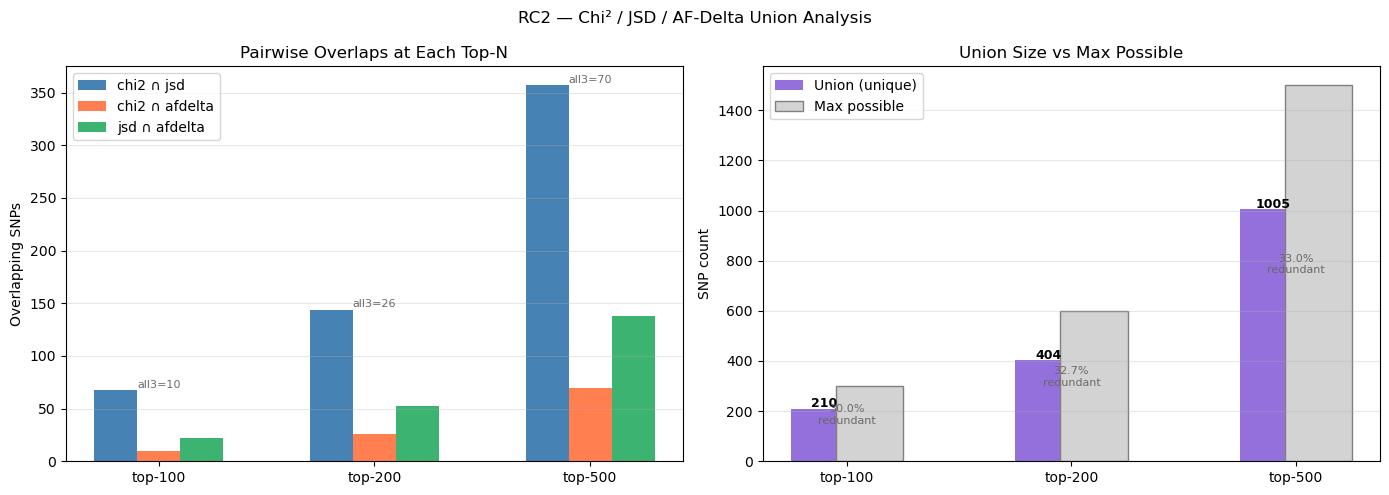

In [8]:
# ── Overlap bar chart across N values ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(top_ns))
width = 0.2
labels = [f"top-{n}" for n in top_ns]

ax = axes[0]
ax.bar(x - width,     summary_df['chi2∩jsd'],     width, label='chi2 ∩ jsd',     color='steelblue')
ax.bar(x,             summary_df['chi2∩afdelta'],  width, label='chi2 ∩ afdelta', color='coral')
ax.bar(x + width,     summary_df['jsd∩afdelta'],   width, label='jsd ∩ afdelta',  color='mediumseagreen')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Overlapping SNPs')
ax.set_title('Pairwise Overlaps at Each Top-N')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# add "all 3" bars
for xi, row in zip(x, summary_rows):
    ax.text(xi, max(row['chi2∩jsd'], row['chi2∩afdelta'], row['jsd∩afdelta']) + 2,
            f"all3={row['all3']}", ha='center', fontsize=8, color='dimgray')

ax2 = axes[1]
ax2.bar(x - width/2, summary_df['union_unique'],  width*1.5, label='Union (unique)',  color='mediumpurple')
ax2.bar(x + width/2, summary_df['max_possible'],  width*1.5, label='Max possible',    color='lightgray',  edgecolor='gray')
for xi, row in zip(x, summary_rows):
    ax2.text(xi - width/2, row['union_unique'] + 5,
             f"{row['union_unique']}", ha='center', fontsize=9, fontweight='bold')
    ax2.text(xi, row['max_possible'] * 0.5,
             f"{row['redundancy_pct']}%\nredundant", ha='center', fontsize=8, color='dimgray')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_ylabel('SNP count')
ax2.set_title('Union Size vs Max Possible')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('RC2 — Chi² / JSD / AF-Delta Union Analysis', fontsize=12)
plt.tight_layout()
plt.savefig(f"{output_prefix}_overlap_summary.png", dpi=150, bbox_inches='tight')
plt.show()

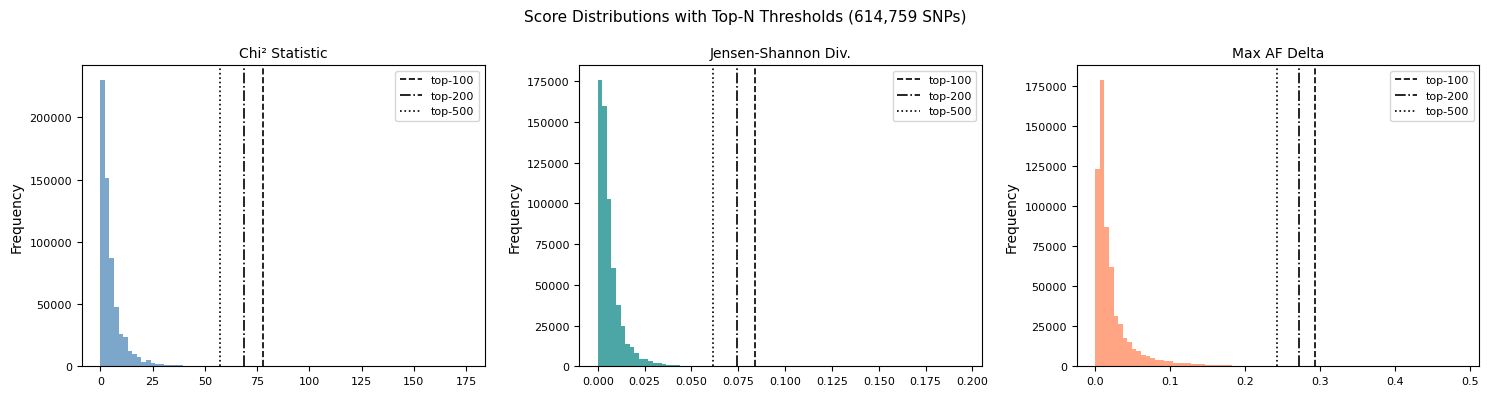

In [9]:
# ── Metric distributions with top-N thresholds marked ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['steelblue', 'teal', 'coral']
configs = [
    ('chi2_stat',   'Chi² Statistic',          'steelblue'),
    ('jsd',         'Jensen-Shannon Div.',      'teal'),
    ('af_max_delta','Max AF Delta',             'coral'),
]
threshold_styles = [('--', '100'), ('-.', '200'), (':', '500')]

for ax, (col, label, color) in zip(axes, configs):
    data = results_df[col].dropna()
    ax.hist(data, bins=80, color=color, alpha=0.7, edgecolor='none')
    sorted_vals = np.sort(data.values)[::-1]
    for N, (ls, lbl) in zip(top_ns, threshold_styles):
        thresh = sorted_vals[N - 1]
        ax.axvline(thresh, linestyle=ls, color='black', linewidth=1.2, label=f'top-{lbl}')
    ax.set_title(label, fontsize=10)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)

plt.suptitle(f'Score Distributions with Top-N Thresholds ({n_snps:,} SNPs)', fontsize=11)
plt.tight_layout()
plt.savefig(f"{output_prefix}_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ── Per-method contribution to each union ────────────────────────────────────
# How many SNPs in the union come exclusively from one method vs shared?
print("Per-method contribution breakdown:\n")
for N in top_ns:
    top_chi2    = set(results_df.nlargest(N, 'chi2_stat')['snp_id'])
    top_jsd     = set(results_df.nlargest(N, 'jsd')['snp_id'])
    top_afdelta = set(results_df.nlargest(N, 'af_max_delta')['snp_id'])

    only_chi2    = top_chi2    - top_jsd    - top_afdelta
    only_jsd     = top_jsd     - top_chi2   - top_afdelta
    only_afdelta = top_afdelta - top_chi2   - top_jsd
    shared_all3  = top_chi2 & top_jsd & top_afdelta
    shared_any2  = (top_chi2 & top_jsd) | (top_chi2 & top_afdelta) | (top_jsd & top_afdelta)
    shared_any2  = shared_any2 - shared_all3

    union = top_chi2 | top_jsd | top_afdelta
    print(f"  Top-{N}  (union={len(union)}):")
    print(f"    Only chi2   : {len(only_chi2):4d}  ({100*len(only_chi2)/len(union):.0f}%)")
    print(f"    Only jsd    : {len(only_jsd):4d}  ({100*len(only_jsd)/len(union):.0f}%)")
    print(f"    Only afdelta: {len(only_afdelta):4d}  ({100*len(only_afdelta)/len(union):.0f}%)")
    print(f"    Shared 2    : {len(shared_any2):4d}  ({100*len(shared_any2)/len(union):.0f}%)")
    print(f"    Shared all 3: {len(shared_all3):4d}  ({100*len(shared_all3)/len(union):.0f}%)")
    print()

Per-method contribution breakdown:

  Top-100  (union=210):
    Only chi2   :   32  (15%)
    Only jsd    :   20  (10%)
    Only afdelta:   78  (37%)
    Shared 2    :   70  (33%)
    Shared all 3:   10  (5%)

  Top-200  (union=404):
    Only chi2   :   56  (14%)
    Only jsd    :   30  (7%)
    Only afdelta:  148  (37%)
    Shared 2    :  144  (36%)
    Shared all 3:   26  (6%)

  Top-500  (union=1005):
    Only chi2   :  143  (14%)
    Only jsd    :   75  (7%)
    Only afdelta:  362  (36%)
    Shared 2    :  355  (35%)
    Shared all 3:   70  (7%)



## Summary

In [11]:
print("=" * 65)
print("02b RC2 — UNION ANALYSIS SUMMARY")
print("=" * 65)
print(f"\nInput:  {n_snps:,} SNPs  |  {n_total} samples  |  {pop_names}")
print(f"\nMethods: Chi² (FDR), Jensen-Shannon Divergence, Max AF Delta")
print(f"Chi² FDR significant at α=0.05: {chi2_reject.sum():,} SNPs\n")

print(f"{'N':>5}  {'Union':>7}  {'Max':>6}  {'Redundancy':>11}  {'All-3 overlap':>14}")
print("-" * 55)
for row in summary_rows:
    N = row['top_n']
    print(f"  {N:>3}  {row['union_unique']:>7}  {row['max_possible']:>6}  "
          f"{row['redundancy_pct']:>10.1f}%  {row['all3']:>14}")

print(f"\nOutput files:")
print(f"  {output_prefix}_all_scores.csv")
for name in ['chi2', 'jsd', 'afdelta']:
    print(f"  {output_prefix}_{name}_ranked.csv")
for N in top_ns:
    print(f"  {output_prefix}_union_top{N}_ids.txt  ← use for ML")
    print(f"  {output_prefix}_union_top{N}_scores.csv")
print(f"\nNext: feed *_union_topN_ids.txt into 04b / 04c ML notebooks.")

02b RC2 — UNION ANALYSIS SUMMARY

Input:  614,759 SNPs  |  504 samples  |  [np.str_('CN'), np.str_('JPT'), np.str_('SEA')]

Methods: Chi² (FDR), Jensen-Shannon Divergence, Max AF Delta
Chi² FDR significant at α=0.05: 30,810 SNPs

    N    Union     Max   Redundancy   All-3 overlap
-------------------------------------------------------
  100      210     300        30.0%              10
  200      404     600        32.7%              26
  500     1005    1500        33.0%              70

Output files:
  /mnt/data/aisnp_data/1000genomes/outputs/statistical_v2/04a_snp_selection_all_scores.csv
  /mnt/data/aisnp_data/1000genomes/outputs/statistical_v2/04a_snp_selection_chi2_ranked.csv
  /mnt/data/aisnp_data/1000genomes/outputs/statistical_v2/04a_snp_selection_jsd_ranked.csv
  /mnt/data/aisnp_data/1000genomes/outputs/statistical_v2/04a_snp_selection_afdelta_ranked.csv
  /mnt/data/aisnp_data/1000genomes/outputs/statistical_v2/04a_snp_selection_union_top100_ids.txt  ← use for ML
  /mnt/data